In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from glob import glob
from skimage import io, color, filters, morphology, measure, exposure

import os
import matplotlib
matplotlib.rcParams.update({'errorbar.capsize': 4})
from matplotlib.patches import Circle

import sys
sys.path.append('../imag_analisis')
# from image_processing import find_fov, offset_circular_mask

In [332]:
def fov_threshold(img, method = ['otsu', 'li', 'yen']):
    from skimage.filters import threshold_otsu, threshold_li, threshold_yen
    threshold = {'otsu': threshold_otsu, 'li': threshold_li, 'yen': threshold_yen}
    img_eq = exposure.equalize_hist(img)
    threshold = threshold[method](img_eq)
    print('Threshold: '+method, threshold)
    binary_mask = img_eq > threshold

    return binary_mask

def make_circular_region(binary_mask):
    """Finding the field of view in a gray image. This will be the disk with the largest area and solidity.
    Args: gray_image: 2D numpy array representing the gray image.
    Returns: fov_mask: 2D numpy array representing the binary mask of the field of view.
    
    """
    # Perform morphological closing to fill small gaps
    binary_mask = morphology.closing(binary_mask, morphology.disk(10))

    # Label connected components
    labeled_mask = measure.label(binary_mask)

    # Measure properties of labeled regions
    regions = measure.regionprops(labeled_mask)

    # Find the largest circular region based on area and solidity
    best_region = None
    best_circularity = 0
    best_area = 100
    for region in regions:
        area = region.area
        perimeter = region.perimeter if region.perimeter > 0 else 1
        circularity = 4 * np.pi * (area / (perimeter ** 2))
        
        if circularity > best_circularity and area > best_area:  # Ignore small noise
            best_circularity = circularity
            best_region = region
            best_area = area

    # Create a mask for the detected FOV
    fov_mask = np.zeros_like(binary_mask, dtype=bool)

    if best_region:
        fov_mask[labeled_mask == best_region.label] = True
    return fov_mask, best_area, best_region

In [333]:
ROOT = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/time/'
path_50 = ROOT + '27-02-25/Rhodamine-B 50 µM 270225/1/*.tif'
files50 = sorted(glob(path_50))

## Total FOV: threshold mask

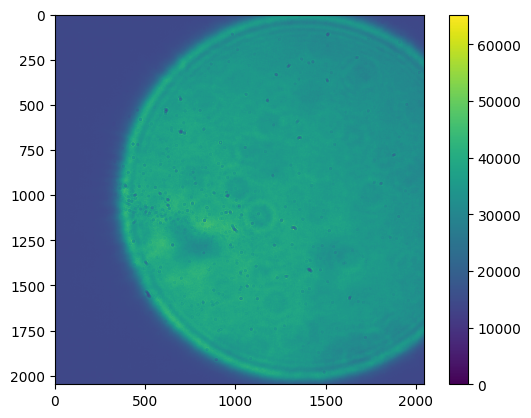

In [334]:
img0 = io.imread(files50[0]).astype(np.int64)
plt.imshow(img0)
plt.colorbar()

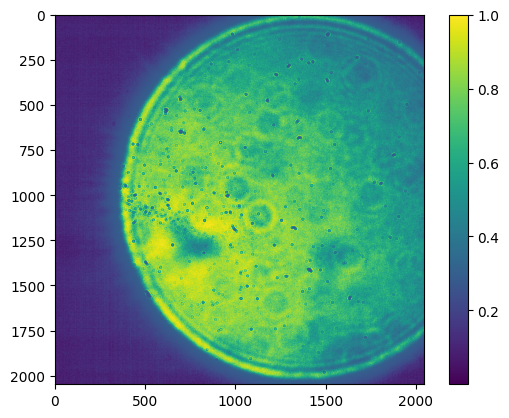

In [335]:
img0 = io.imread(files50[0]).astype(np.int64)
img_eq0 = exposure.equalize_hist(img0)

plt.imshow(img_eq0)
# img_eq0[~mask] = 0
plt.colorbar()

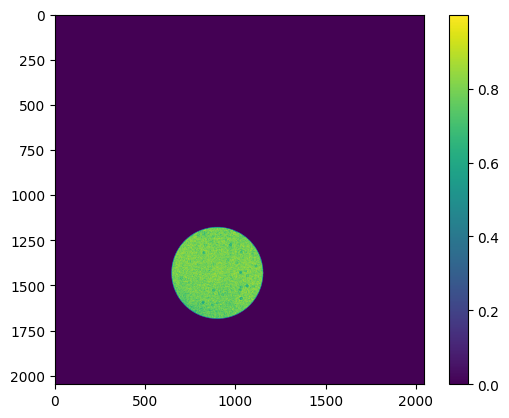

In [336]:
img400 = io.imread(files50[350]).astype(np.int64)

img_eq = exposure.equalize_hist(img400)
img_eq[~mask] = 0
plt.imshow(img_eq)
plt.colorbar()

Threshold otsu:  0.6640824605710804


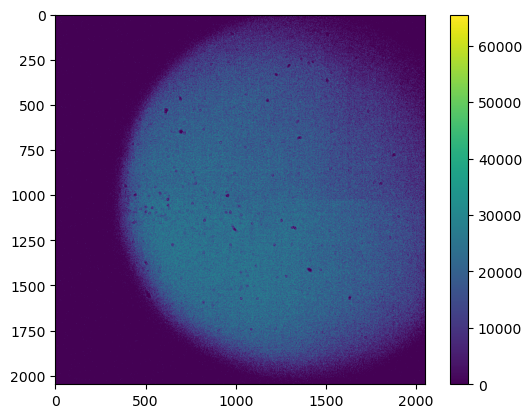

In [114]:
mask = fov_threshold(img0)
img0[~mask] = 0
plt.imshow(img0)
plt.colorbar()

In [337]:
def average_tevol(data):
    I, J = np.shape(data[0])
    av_evol = np.zeros_like(data[:, 0, 0])
    for i in range(I):
        for j in range(J):
            av_evol += data[:, i, j]
    av_evol = av_evol/(I*J)

    return av_evol

In [338]:
len(img0[mask].ravel())

201331

In [339]:
roi_size = len(img0[mask].ravel())

avg_ints = []
for f in files50:
    img = io.imread(f).astype(np.int64)
    img[~mask] = 0
    avg_int = img.sum() / roi_size
    avg_ints.append(avg_int)


[Text(0.5, 0, 'N frames'), Text(0, 0.5, 'Average counts whole FOV')]

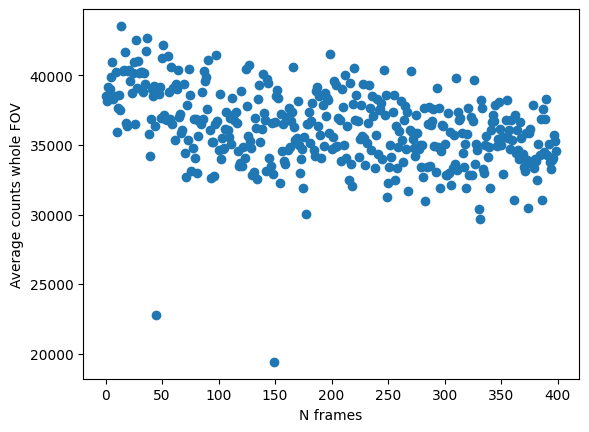

In [340]:
plt.plot(avg_ints, 'o')
plt.gca().set(xlabel='N frames', ylabel='Average counts whole FOV')

/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_97468/3107839695.py:15: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * t) + c
/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_97468/3107839695.py:15: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * t) + c


[Text(0.5, 0, 't (s)'), Text(0, 0.5, 'Average counts in FOV')]

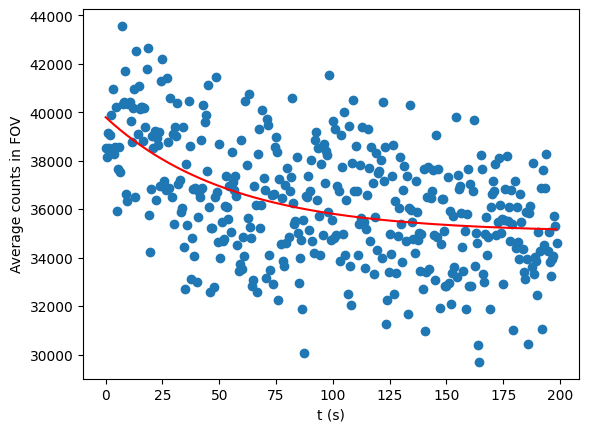

In [349]:
avg_fov = np.array(avg_ints)

def remove_outliers(avg_fov):
    cutlow = np.average(avg_fov) - 3*np.std(avg_fov)
    cuthigh = np.average(avg_fov) + 3*np.std(avg_fov)
    avg_fov_low = avg_fov[avg_fov > cutlow]
    avg_fov_out = avg_fov_low[avg_fov_low < cuthigh]
    return avg_fov_out

avg_fov_out = remove_outliers(avg_fov)
texp = 0.5
x_time = np.arange(0, texp*len(avg_fov_out), texp)

def exponential_fit(t, a, b, c):
    return a * np.exp(-b * t) + c

from scipy.optimize import curve_fit
popt, pcov = curve_fit(exponential_fit, x_time, avg_fov_out, p0=[42000, 1, 30000])

plt.plot(x_time, avg_fov_out, 'o')
plt.plot(x_time, exponential_fit(x_time, *popt), 'r-')
plt.gca().set(xlabel='t (s)', ylabel='Average counts in FOV')


### Try quantile 0.9 and sum

In [ ]:
np.quantile(img, 0.9), np.max(img), np.average(img), np.sum(img)

(36500.0, 65500, 31801.998674869537, 133387250250)

In [ ]:
roi_size = len(img0[mask].ravel())

avg_ints = []
quant90 = []
sums = []
for f in files50:
    img = io.imread(f).astype(np.int64)
    img[~mask] = 0
    avg_int = img.sum() / roi_size
    avg_ints.append(avg_int)

    max_ar.append(np.max(img))
    quant90.append(np.quantile(img, 0.9))
    sums.append(np.sum(img))

avg_ints = np.array(avg_ints)
quant90 = np.array(quant90)
sums = np.array(sums)

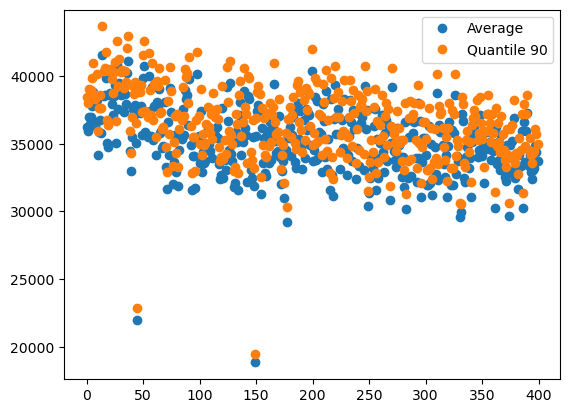

In [220]:
plt.plot(avg_ints, 'o', label='Average')
# plt.plot(max_ar, 'o', label='Maxima')
plt.plot(quant90, 'o', label='Quantile 90')
plt.legend()

## Try equalizing 

In [186]:
roi_size = len(img0[mask].ravel())

avg_ints_eq = []
for f in files50:
    img = io.imread(f).astype(np.int64)
    img_eq = exposure.equalize_hist(img)

    # img_eq[~mask] = 0
    avg_int = img_eq.sum() / len(img_eq.ravel())
    avg_ints_eq.append(avg_int)

[Text(0, 0.5, 'Average counts whole FOV'),
 Text(0.5, 0, 'N frames'),
 Text(0.5, 1.0, 'Equalization')]

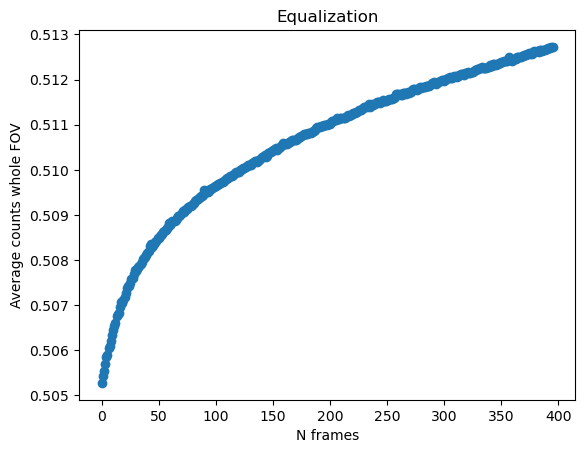

In [187]:
avg_eq_out = remove_outliers(np.array(avg_ints_eq))
plt.plot(avg_eq_out, 'o')
plt.gca().set(xlabel='N frames', ylabel='Average counts whole FOV', title='Equalization')


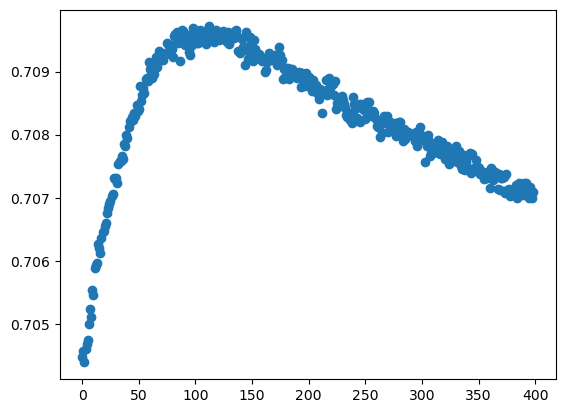

In [ ]:
# avg_eq_out = remove_outliers(np.array(avg_ints_eq))
plt.plot(avg_eq_out, 'o')
plt.gca().set(xlabel='N frames', ylabel='Average counts whole FOV', title='Equalization + mask')


# With smaller ROI

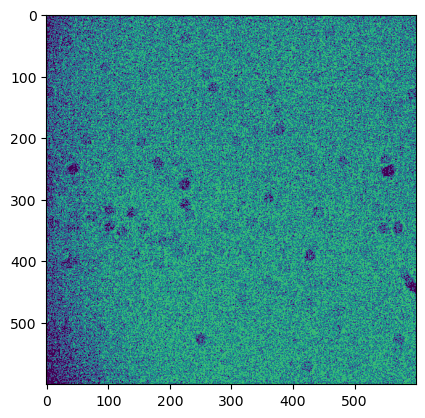

In [125]:
roi = [750, 1350, 400, 1000]
imroi0 = img0[roi[0]:roi[1], roi[2]:roi[3]]
plt.imshow(imroi0)

In [140]:
roi_size = len(imroi0.ravel())

avg_ints = []
for f in files50:
    img = io.imread(f).astype(np.int64)
    imroi = img[roi[0]:roi[1], roi[2]:roi[3]]
    avg_int = imroi.sum() / roi_size
    avg_ints.append(avg_int)

[Text(0, 0.5, 'Average counts 600x600 ROI'), Text(0.5, 0, 'N frames')]

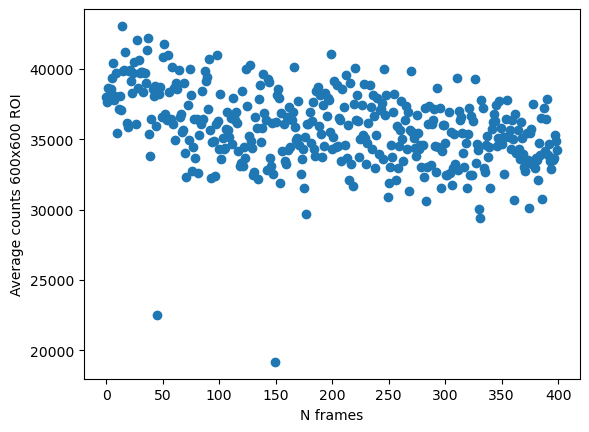

In [141]:
plt.plot(avg_ints, 'o')
plt.gca().set(xlabel='N frames', ylabel='Average counts 600x600 ROI')


# Follow a single pixel

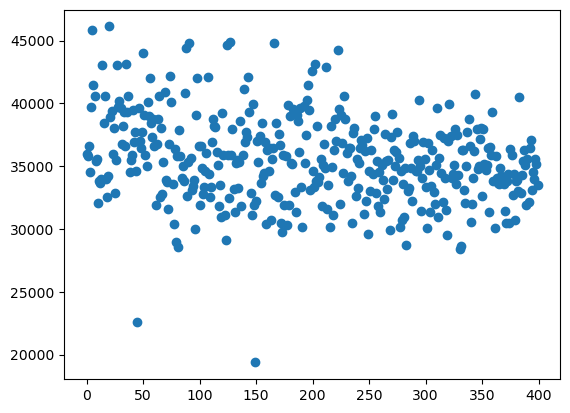

In [222]:
I, J = 1000, 1000
time_ev = []
for f in files50:
    px_int = io.imread(f).astype(np.int64)[I, J]
    time_ev.append(px_int)
plt.plot(time_ev, 'o')

# Rhodamine B 5 µM 27022025

In [ ]:
def calculate_trajectories(files, mask):
    files.sort()
    img0 = io.imread(files[0]).astype(np.int64)
    roi_size = len(img0[mask].ravel())
    avg_ints = []

    for f in files:
        img = io.imread(f).astype(np.int64)
        img[~mask] = 0
        avg_int = img.sum() / roi_size
        avg_ints.append(avg_int)

        # quant90.append(np.quantile(img, 0.9))
        # sums.append(np.sum(img))

    avg_ints = np.array(avg_ints)
    # quant90 = np.array(quant90)
    # sums = np.array(sums)
    return avg_ints

In [ ]:
from skimage.filters import try_all_threshold, threshold_li, threshold_yen

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


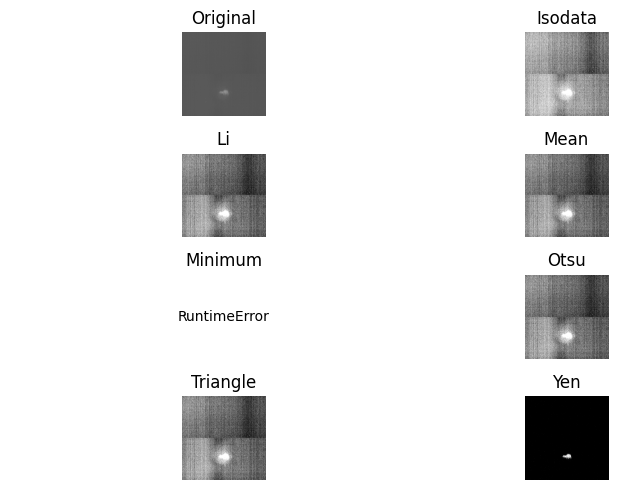

In [ ]:
img400 = io.imread(files5[399]).astype(np.int64)

fig, ax = try_all_threshold(img400)

In [ ]:
path_5 = ROOT + '27-02-25/Rhodamine-B 5 µM 270225/1/*.tif'
files5 = sorted(glob(path_5))
img0 = io.imread(files5[0]).astype(np.int64)

mask_otsu = fov_threshold(img0, 'otsu')
mask_li = fov_threshold(img0, 'li')
mask_yen = fov_threshold(img0, 'yen')

Threshold: otsu 0.5058594928123057
Threshold: li 0.5075693775918166
Threshold: yen 0.9511718866415322


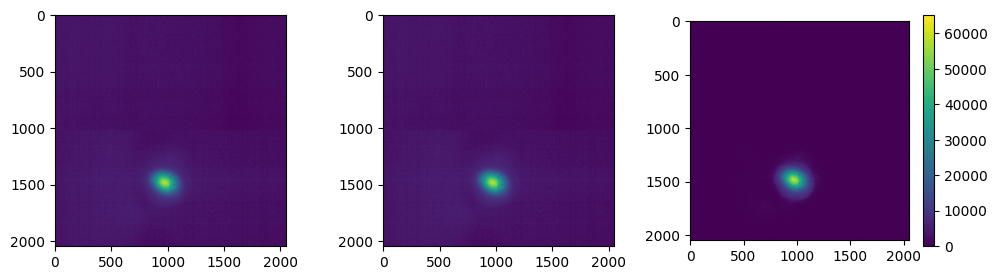

In [46]:
im_ostu = img0*mask_otsu
im_li = img0*mask_li
im_yen = img0*mask_yen

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
i1 = ax[0].imshow(im_ostu)
i2 = ax[1].imshow(im_li)
i3 = ax[2].imshow(im_yen)
# for i, a in zip([i1, i2, i3], ax):
plt.colorbar(i3, ax=ax[2]) 

In [ ]:
avg_otsu = calculate_trajectories(files5, mask=mask_otsu)
avg_li = calculate_trajectories(files5, mask=mask_li)
avg_yen = calculate_trajectories(files5, mask=mask_yen)

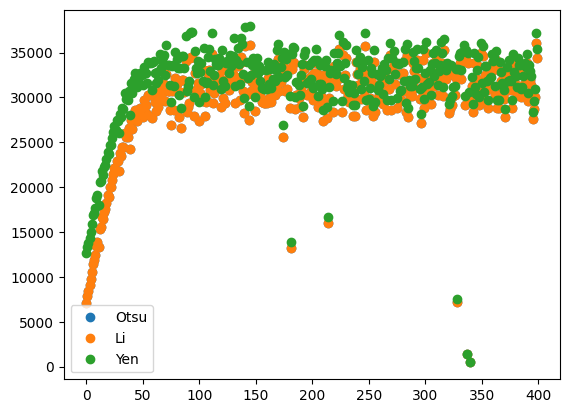

In [29]:
plt.plot(avg_otsu, 'o', label='Otsu')
plt.plot(avg_li, 'o', label='Li')
plt.plot(avg_yen, 'o', label='Yen')
plt.legend()

In [74]:
np.argwhere(mask_yen[1000, :] )
mask_yen[1000, 1063]

True

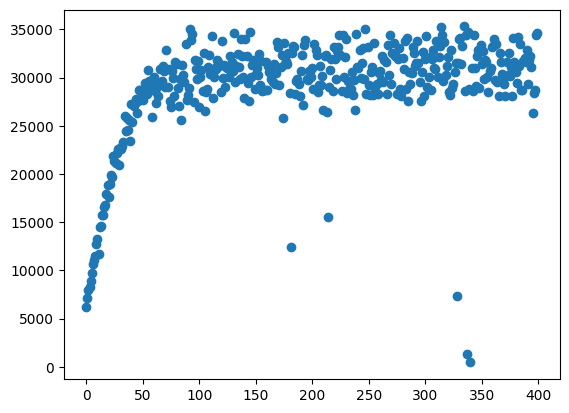

In [75]:
I, J = 1000, 1063
time_ev = []
for f in files5:
    px_int = io.imread(f).astype(np.int64)[I, J]
    time_ev.append(px_int)
plt.plot(time_ev, 'o')

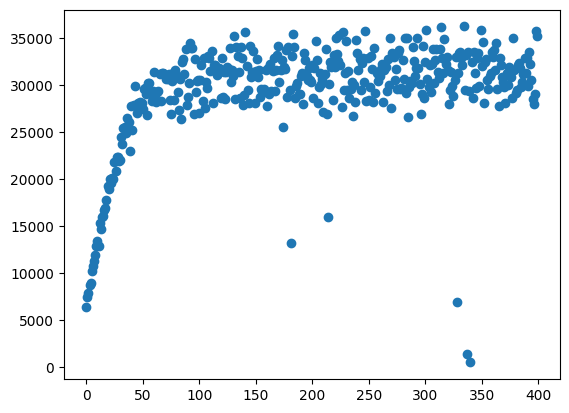

In [79]:
I, J = 0, 0
time_ev = []
for f in files5:
    px_int = io.imread(f).astype(np.int64)[I, J]
    time_ev.append(px_int)
plt.plot(time_ev, 'o')

# Rhodamine B 0.5 µM

In [82]:
path_05 = ROOT + '27-02-25/Rhodamine-B 0.5 µM 270225/1/*.tif'
files05 = sorted(glob(path_05))
img0 = io.imread(files05[0]).astype(np.int64)

mask_otsu = fov_threshold(img0, 'otsu')
mask_li = fov_threshold(img0, 'li')
mask_yen = fov_threshold(img0, 'yen')

Threshold: otsu 0.3964845188893378
Threshold: li 0.44650514015613757
Threshold: yen 0.9550781357102096


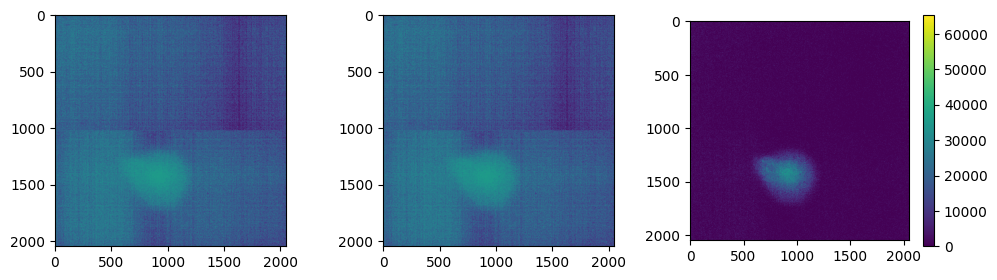

In [51]:
im_ostu = img0*mask_otsu
im_li = img0*mask_li
im_yen = img0*mask_yen

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
i1 = ax[0].imshow(im_ostu)
i2 = ax[1].imshow(im_li)
i3 = ax[2].imshow(im_yen)
# for i, a in zip([i1, i2, i3], ax):
plt.colorbar(i3, ax=ax[2]) 

In [77]:
avg_otsu = calculate_trajectories(files05, mask=mask_otsu)
avg_li = calculate_trajectories(files05, mask=mask_li)
avg_yen = calculate_trajectories(files05, mask=mask_yen)

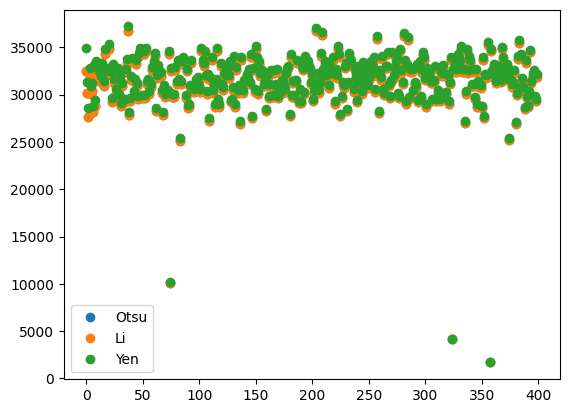

In [78]:
plt.plot(avg_otsu, 'o', label='Otsu')
plt.plot(avg_li, 'o', label='Li')
plt.plot(avg_yen, 'o', label='Yen')
plt.legend()

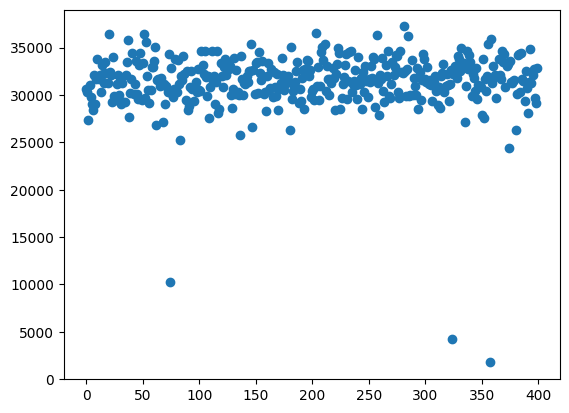

In [97]:
I, J = 0, 0
time_ev = []
for f in files05:
    px_int = io.imread(f).astype(np.int64)[I, J]
    time_ev.append(px_int)
plt.plot(time_ev, 'o')

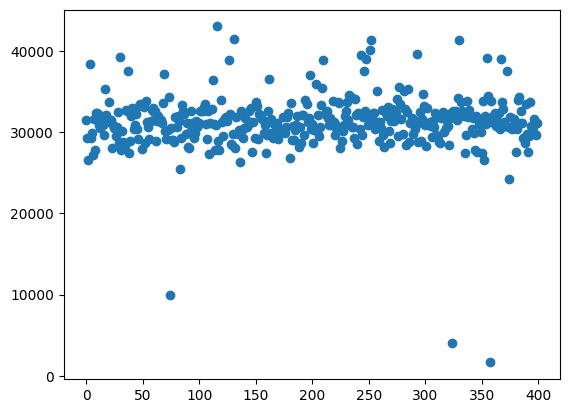

In [96]:
I, J = 1000, 1000
time_ev = []
for f in files05:
    px_int = io.imread(f).astype(np.int64)[I, J]
    time_ev.append(px_int)
plt.plot(time_ev, 'o')

In [93]:
len(mask_otsu[mask_otsu]), len(mask_yen[mask_yen]), len(mask_li[mask_li]), len(mask_otsu.ravel())

(2534098, 193337, 2534098, 4194304)

In [88]:
np.argwhere(mask_yen )

array([[   0,   34],
       [   0,   36],
       [   0,   39],
       ...,
       [2047, 1970],
       [2047, 1982],
       [2047, 2015]])

# Develop FOV finding algorithm and generalize to faint FOVs:

In [199]:
path_05 = ROOT + '27-02-25/Rhodamine-B 0.5 µM 270225/1/*.tif'
files05 = sorted(glob(path_05))
img0 = io.imread(files05[0]).astype(np.int64)
# img0 = exposure.equalize_hist(img0)

mask_otsu = fov_threshold(img0, 'otsu')
mask_li = fov_threshold(img0, 'li')
mask_yen = fov_threshold(img0, 'yen')

fov_otsu, area_otsu, region_otsu = make_circular_region(mask_otsu)
fov_li, area_li, region_li = make_circular_region(mask_li)
fov_yen, area_yen, region_yen = make_circular_region(mask_yen)

Threshold: otsu 0.3964845188893378
Threshold: li 0.44650514015613757
Threshold: yen 0.9550781357102096


In [113]:
region_yen.perimeter, region_yen.centroid

(78.56244584051393, (988.3543689320388, 1589.4611650485438))

In [115]:
region_yen.bbox

(975, 1580, 999, 1603)

In [116]:
from matplotlib.patches import Rectangle

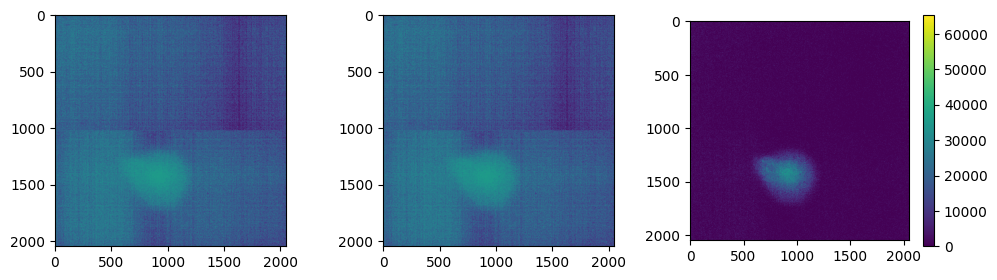

In [126]:
im_ostu = img0*mask_otsu
im_li = img0*mask_li
im_yen = img0*mask_yen

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
i1 = ax[0].imshow(im_ostu)
i2 = ax[1].imshow(im_li)
i3 = ax[2].imshow(im_yen)

# for i, a in zip([i1, i2, i3], ax):
plt.colorbar(i3, ax=ax[2]) 

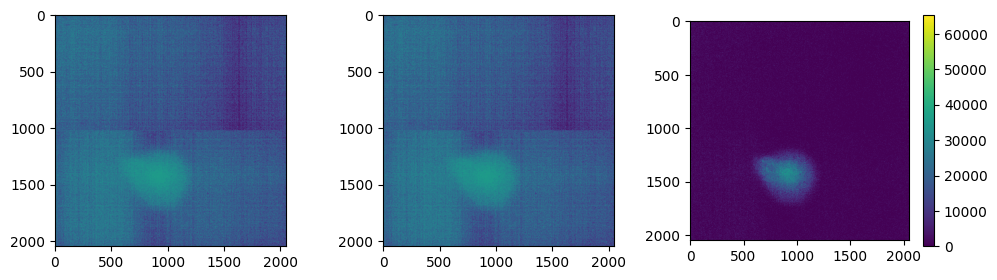

In [127]:
im_ostu = img0*mask_otsu
im_li = img0*mask_li
im_yen = img0*mask_yen

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
i1 = ax[0].imshow(im_ostu)
i2 = ax[1].imshow(im_li)
i3 = ax[2].imshow(im_yen)

# for i, a in zip([i1, i2, i3], ax):
plt.colorbar(i3, ax=ax[2]) 

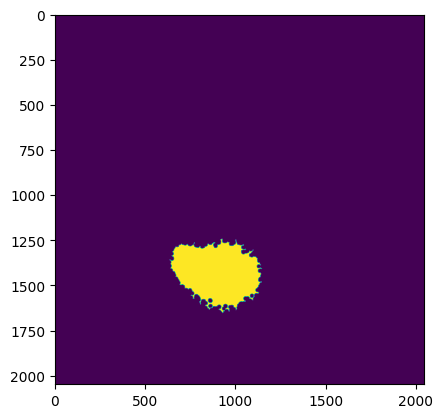

In [ ]:
binary = morphology.remove_small_objects(mask_yen, min_size=10)

fov, _, region = make_circular_region(binary)
# 5) Find the region whose centroid is closest to (row=1589, col=988)
plt.imshow(fov)

In [152]:
region.bbox, 1145-635, 1655 - 1244

((1244, 635, 1655, 1145), 510, 411)

In [150]:
region.axis_major_length, region.axis_minor_length

(506.29222702905804, 342.43624255121034)

In [160]:
from skimage.draw import disk

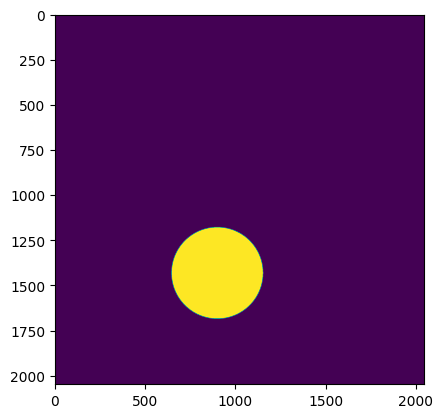

In [165]:

mask = np.zeros_like(img0, dtype=bool)
rr, cc = disk(center=region.centroid, radius=region.axis_major_length/2, shape=mask.shape)
mask[rr, cc] = True
plt.imshow(mask)

In [250]:
def find_fov(img, method = ['None', 'otsu', 'li', 'yen']):
    """Full FOV detection in a gray image.
    Args: gray_image: 2D numpy array representing the gray image.
    Returns: fov_mask: 2D numpy array representing the binary mask of the field of view.
    
    """
    
    if method == 'None':
        method = 'yen'
    binary_mask = fov_threshold(img, method)
    
    binary_mask = morphology.remove_small_objects(binary_mask, min_size=10)  # Remove small noise
    fov_mask, area, region = make_circular_region(binary_mask)   # Find the most circular region in the mask, this is the fine grained FOV

    mask_disk = np.zeros_like(img, dtype=bool)
    rr, cc = disk(center=region.centroid, radius=region.axis_major_length/2, shape=mask_disk.shape)   # Make a perfect circular mask
    mask_disk[rr, cc] = True

    plt.imshow(mask_disk * img)
    plt.colorbar()
    plt.show()
    return mask_disk

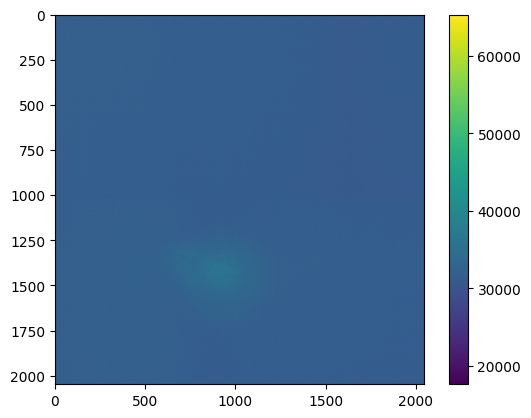

In [176]:
plt.imshow( img0)
plt.colorbar()

Threshold: yen 0.9550781357102096


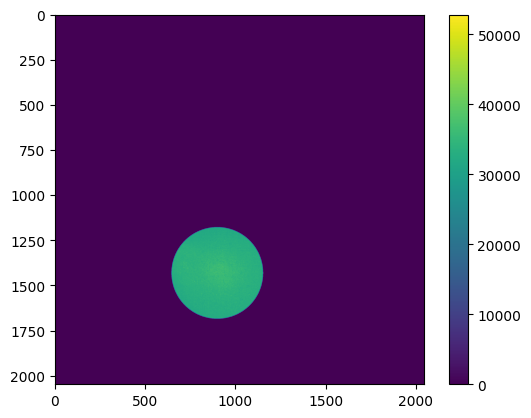

In [237]:
mask_disk = find_fov(img0, method='yen')

plt.imshow(mask_disk * img0)
plt.colorbar()

## Generalize to other FOVs?

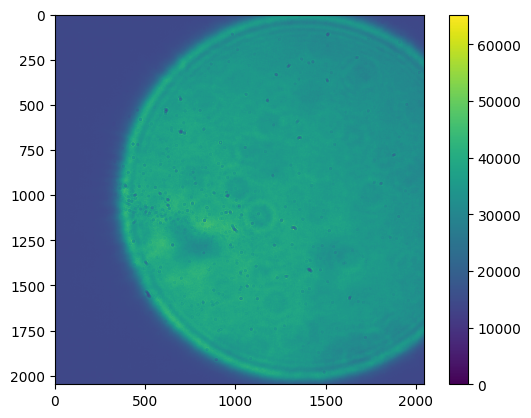

In [232]:
img50 = io.imread(files50[0]).astype(np.int64)
plt.imshow(img50)
plt.colorbar()

Threshold: otsu 0.5019532437436283


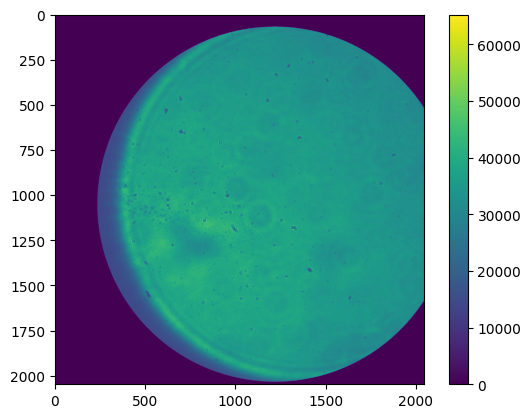

In [240]:
mask_disk = find_fov(img50, 'otsu')
plt.imshow(mask_disk * img50)
plt.colorbar()

### Debug 

Threshold: yen 0.6308594630099833


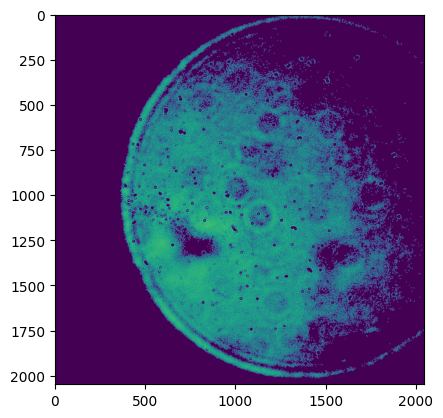

In [224]:
method = 'yen'
img = img50
binary_mask = fov_threshold(img, method)
    
binary_mask = morphology.remove_small_objects(binary_mask, min_size=10)  # Remove small noise
plt.imshow(img50 * binary_mask)

In [225]:
fov_mask, area, region = make_circular_region(binary_mask)   # Find the most circular region in the mask, this is the fine grained FOV

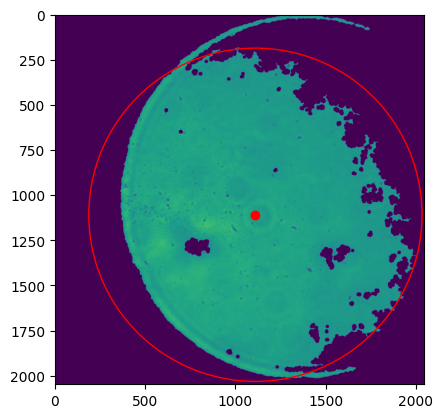

In [226]:
plt.imshow(img50 * fov_mask)
plt.scatter(region.centroid[1], region.centroid[0], color='red')
plt.gca().add_patch(Circle(region.centroid, region.axis_major_length/2, fill=False, color='red'))

In [272]:
os.getcwd(), os.listdir('../imag_analisis/')

('/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/notebooks',
 ['.DS_Store',
  'quick_spectra.py',
  'fluorecentV2.py',
  'get_trajectories.py',
  'fluorecentV3.py',
  'focustest',
  'old',
  'NONAME001.BMP',
  '__pycache__',
  'fluorecent.py',
  'filter_stats.csv',
  'profile_laser_on_sample.py',
  'image_processing.py'])

In [284]:
path = '../imag_analysis/filter_stats.csv'

filtQE = pd.read_csv('../imag_analisis/filter_stats.csv')
filtQE[:11]

,Unnamed: 0,central_lambda,range_width,mean_qe,range_low,range_high
0,filter03_438nm,438.3,13.8,0.934,424.3,452.0
1,filter04_472nm,472.0,15.7,0.898,456.4,487.8
2,filter05_549nm,547.7,10.1,0.969,537.6,557.8
3,filter06_575nm,575.5,15.5,0.973,560.0,591.0
4,filter07_586nm,590.0,12.2,0.964,577.8,602.2
5,filter08_605nm,605.4,10.3,0.966,595.1,615.7
6,filter09_631nm,630.7,13.4,0.963,617.3,644.0
7,filter10_661nm,662.1,11.1,0.947,651.0,673.2
8,filter11_676nm,676.2,16.6,0.967,659.5,692.7
9,filter12_692nm,693.1,22.6,0.971,670.4,715.6


In [ ]:
REFERENCE_DIR = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/spectra/emission/'
def plot_reference_spectrum(name):
    file = REFERENCE_DIR + name + '.csv'
    df_ref = pd.read_csv(file, names=['wv', 'counts'], skiprows=1, index_col='wv')
    plt.plot(df_ref, '-', label=name)
    plt.gca().set(xlabel='Wavelength (nm)', ylabel='Counts')

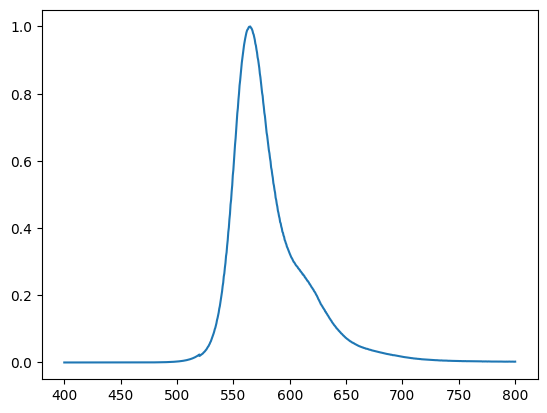

In [330]:
pathfake = '/img/sets/04-03-25/Rhodamine-B 50 µM 270225'
if 'Rhodamine' in pathfake:
    plot_reference_spectrum('Rhodamine')